# K-means segmentace chování účastníků pomocí PROC FASTCLUS



## Shrnutí

Tento notebook rozděluje syntetickou základnu 100 mobilních účastníků do behaviorálních segmentů pomocí `PROC FASTCLUS`, procedury Base SAS pro k-means shlukování. Sedm ukazatelů využití je standardizováno na z-skóre pomocí `PROC STDIZE`, aby proměnné s vysokými hodnotami (hlasové minuty, počet SMS) nedominovaly euklidovské vzdálenosti, poté `PROC FASTCLUS` vytvoří tři shluky. Procedura hlásí průměrnou kvadratickou odchylku uvnitř shluku, celkové R-kvadrát a pseudo-F, které vyjadřují, jak dobře segmentace odděluje základnu (zde celkové R-kvadrát 0,575 a pseudo-F 65,75), a zapíše ohodnocenou tabulku se štítkem `CLUSTER` u každého účastníka. Tyto štítky sloučíme zpět s daty v původním měřítku, popíšeme jednotlivé persony a předáme přiřazení navazující aktivaci.


## Zdroje dat

| Datová sada | Popis | Řádky | Klíčové proměnné |
| ------- | ----------- | ---: | ------------- |
| `subscribers` | Syntetický měsíční snímek chování pro základnu účastníků mobilního operátora, vygenerovaný přímo pomocí `call streaminit` / `rand()`. Tři latentní typy chování (vysoká spotřeba dat, orientace na hlas, nízké využití) jsou smíchány se šumem. | 100 | `subscriber_id`, `tenure_months`, `monthly_data_gb`, `voice_minutes`, `sms_count`, `arpu`, `intl_minutes`, `support_calls`, `data_plan` (nominální), `region` (nominální) |


# K-means segmentace chování účastníků

**Odvětví:** Telekomunikace &nbsp;|&nbsp; **Procedura:** `PROC FASTCLUS` (Base SAS k-means shlukování)

Mobilní operátoři mají účastníky, jejichž měsíční chování -- chuť na data, hlasové návyky, útrata a zátěž podpory -- spadá do několika rozpoznatelných vzorců. Odhalení těchto vzorců umožňuje firmě přizpůsobit retenční nabídky, nabízet správné balíčky a získávat podobné zákazníky. Tento notebook postaví behaviorální segmentaci od začátku do konce: vygeneruje realistický snímek účastníků, standardizuje ukazatele, nechá `PROC FASTCLUS` vytvořit shluky, ohodnotí každého účastníka a popíše segmenty jako využitelné persony. `PROC FASTCLUS` je navržen přesně pro tuto úlohu disjunktního k-means shlukování a škáluje na velmi velké základny, protože prochází data postupně, místo aby sestavoval úplnou matici vzdáleností.


## 1. Vygenerování syntetické základny účastníků

Simulujeme 100 účastníků vycházejících ze tří latentních behaviorálních archetypů -- **uživatelé s vysokou spotřebou dat**, **hlasově orientovaní tradicionalisté** a zákazníci s **nízkým/lehkým využitím** -- a poté přimícháme šum, aby byly hranice neostré (jako ve skutečnosti). Každý účastník také nese dva kategoriální atributy, `data_plan` a `region`, které později použijeme k *profilaci* segmentů. Náhodné semínko zajišťuje reprodukovatelnost dat.


In [1]:
/* -----------------------------------------------------------
   Syntetický měsíční snímek 100 mobilních účastníků.
   Tři latentní behaviorální archetypy + šum, plus dva
   kategoriální atributy pro profilaci segmentů.
   ----------------------------------------------------------- */
data subscribers;
    CALL streaminit(20260531);

    DÉLKA data_plan $20 region $12;

    OPAKUJ subscriber_id = 100001 TO 100100;

        /* latentní archetyp: 1=vysoká spotřeba dat, 2=hlas, 3=nízké využití */
        u = rand('uniform');
        KDYŽ      u < 0.38 PAK archetype = 1;
        JINAK KDYŽ u < 0.70 PAK archetype = 2;
        JINAK                  archetype = 3;

        tenure_months = MAX(1, round(rand('gamma', 2.2) * 12));

        KDYŽ archetype = 1 PAK OPAKUJ;             /* uživatel s vysokou spotřebou dat */
            monthly_data_gb = MAX(0.5, rand('normal', 42, 11));
            voice_minutes   = MAX(0,   rand('normal', 180, 70));
            sms_count       = MAX(0,   round(rand('normal', 60, 30)));
            intl_minutes    = MAX(0,   rand('normal', 22, 14));
            arpu            = MAX(15,  rand('normal', 78, 14));
            support_calls   = rand('poisson', 0.8);
            planpick = ifn(rand('uniform') < 0.65, 3, 2);
        KONEC;
        JINAK KDYŽ archetype = 2 PAK OPAKUJ;        /* hlasově orientovaný */
            monthly_data_gb = MAX(0.2, rand('normal', 9, 4));
            voice_minutes   = MAX(0,   rand('normal', 620, 160));
            sms_count       = MAX(0,   round(rand('normal', 210, 80)));
            intl_minutes    = MAX(0,   rand('normal', 95, 45));
            arpu            = MAX(12,  rand('normal', 55, 12));
            support_calls   = rand('poisson', 1.6);
            planpick = ifn(rand('uniform') < 0.55, 2, 1);
        KONEC;
        JINAK OPAKUJ;                              /* nízké využití */
            monthly_data_gb = MAX(0.1, rand('normal', 3, 1.5));
            voice_minutes   = MAX(0,   rand('normal', 110, 50));
            sms_count       = MAX(0,   round(rand('normal', 35, 20)));
            intl_minutes    = MAX(0,   rand('normal', 6, 6));
            arpu            = MAX(8,   rand('normal', 26, 7));
            support_calls   = rand('poisson', 0.5);
            planpick = ifn(rand('uniform') < 0.70, 1, 2);
        KONEC;

        KDYŽ planpick = 1 PAK data_plan = 'Předplacený';
        JINAK KDYŽ planpick = 2 PAK data_plan = 'Paušál';
        JINAK data_plan = 'Neomezený';

        regionpick = rand('table', 0.30, 0.28, 0.22, 0.20);
        KDYŽ regionpick = 1 PAK region = 'Sever';
        JINAK KDYŽ regionpick = 2 PAK region = 'Jih';
        JINAK KDYŽ regionpick = 3 PAK region = 'Východ';
        JINAK region = 'Západ';

        /* zaokrouhlení na přehlednou přesnost pro reporting */
        monthly_data_gb = round(monthly_data_gb, 0.1);
        voice_minutes   = round(voice_minutes,   1);
        intl_minutes    = round(intl_minutes,    1);
        arpu            = round(arpu,            0.01);

        VÝSTUP;
    KONEC;

    PONECHAT subscriber_id tenure_months monthly_data_gb voice_minutes
         sms_count intl_minutes arpu support_calls data_plan region;
SPUSTIT;



NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. Prozkoumání rozdělení ukazatelů

Před shlukováním se podívejme na měřítko a rozptyl každého behaviorálního ukazatele. Zcela odlišné jednotky -- gigabajty, minuty, dolary, počty -- jsou přesně důvodem, proč před shlukováním standardizujeme intervalové vstupy; jinak by proměnné s vysokými hodnotami jako `voice_minutes` dominovaly euklidovské vzdálenosti, kterou `PROC FASTCLUS` minimalizuje.


                                                  The MEANS Procedure

 Variable         Label                                N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 -----------------------------------------------------------------------------------------------------------------------------------------------------
 tenure_months    Doba u operátora (měsíce)          100        27.6        18.9         3.0             13.0        22.0             37.5        98.0
 monthly_data_gb  Měsíční data (GB)                  100        18.2        18.9         0.1              3.7         9.6             31.5        67.2
 voice_minutes    Hlasové minuty                     100       304.2       236.6         0.0            125.0       217.0            527.5       912.0
 sms_count        Počet SMS                          100       102.0       102.6         0.0             35.0        64.0            130.0       404.0
 intl_minutes     Zahra


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_data_plan.spec.json
NOTE: ODS plot written: freq_region.spec.json
NOTE: PROC FREQ statement used.


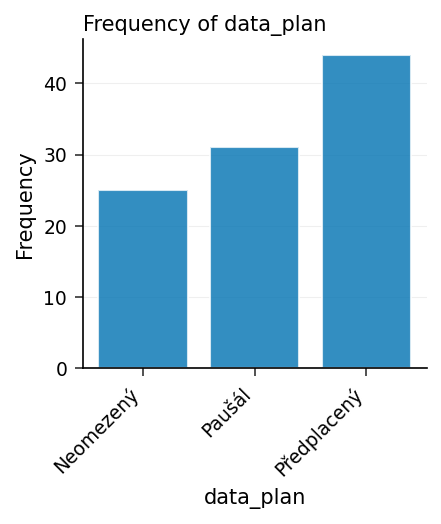

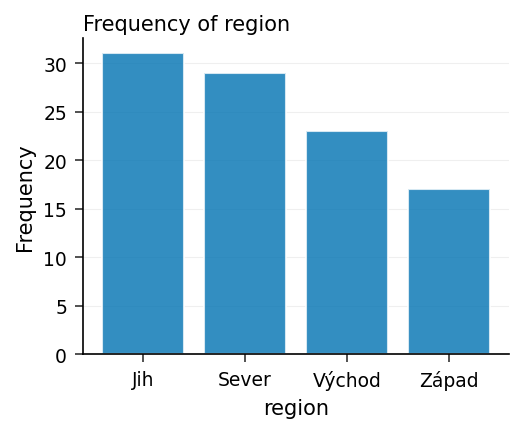

In [2]:
/* Souhrnné statistiky pro vstupy shlukování */
PROCEDURA PRŮMĚRY data=subscribers n mean std MIN p25 MEDIAN p75 MAX maxdec=1;
    ŠTÍTEK tenure_months="Doba u operátora (měsíce)" monthly_data_gb="Měsíční data (GB)"
          voice_minutes="Hlasové minuty" sms_count="Počet SMS"
          intl_minutes="Zahraniční minuty" arpu="ARPU ($)" support_calls="Volání na podporu";
    PROMĚNNÁ tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
SPUSTIT;

/* Četnost dvou kategoriálních vstupů */
PROCEDURA ČETNOSTI data=subscribers;
    ŠTÍTEK data_plan="Tarif" region="Region";
    TABLES data_plan region / nocum;
SPUSTIT;


## 3. Standardizace ukazatelů na z-skóre

`PROC FASTCLUS` minimalizuje euklidovskou vzdálenost, takže proměnná měřená ve stovkách minut by přehlušila proměnnou měřenou v jednotkách gigabajtů. `PROC STDIZE` s `METHOD=STD` přeškáluje každý intervalový ukazatel na průměr 0 a směrodatnou odchylku 1, čímž dá každému chování stejnou váhu ve vzdálenosti. Kategoriální sloupce a identifikátor projdou beze změny, abychom mohli později profilovat shluky v původním měřítku.


In [3]:
/* z-skóre intervalových ukazatelů; id a kategorie beze změny */
PROCEDURA stdize data=subscribers out=subs_std METHOD=std;
    PROMĚNNÁ tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
SPUSTIT;



NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std


## 4. Vytvoření k-means segmentace

Vytvoříme tři segmenty pomocí `PROC FASTCLUS`. `MAXCLUSTERS=3` nastavuje *k*; `MAXITER=20` umožňuje středům shluků iterovat ke konvergenci. Procedura hlásí **souhrn shluků** (velikost a průměrnou kvadratickou odchylku uvnitř shluku pro každý shluk), **statistiky pro proměnné** (R-kvadrát, kterým každý ukazatel přispívá), **celkové R-kvadrát** a **pseudo-F**, které měří, jak čistě tři shluky oddělují základnu, a **průměry shluků** ve standardizovaném měřítku. `OUT=scored` zapíše vstupní řádky zpět se štítkem `CLUSTER` a `DISTANCE` každého účastníka od jádra jeho shluku.


In [4]:
/* k-means fit na standardizovaných ukazatelích: 3 segmenty. */
PROCEDURA FASTCLUS data=subs_std maxclusters=3 MAXITER=20 out=scored;
    ŠTÍTEK tenure_months="Doba u operátora (měsíce)" monthly_data_gb="Měsíční data (GB)"
          voice_minutes="Hlasové minuty" sms_count="Počet SMS"
          intl_minutes="Zahraniční minuty" arpu="ARPU ($)" support_calls="Volání na podporu";
    PROMĚNNÁ tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
SPUSTIT;



                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=20                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  36         0.5293             2.6279              3         3.0809
2                  34         0.7925             3.4184              3         3.5916
3                  30         0.6295             3.9300              1         3.0809

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 7 variables, 3 clusters using k-means


## 5. Připojení štítků segmentů k datům v původním měřítku

Ohodnocená tabulka obsahuje standardizované ukazatele; pro profilaci chceme popsat shluky ve skutečných gigabajtech, minutách a dolarech. Sloučíme štítek `CLUSTER` zpět s původní tabulkou `subscribers` podle `subscriber_id` a poté si položíme první otázku, kterou si marketing vždy klade: *jak velký je každý segment?*


                                                   The FREQ Procedure

Segment    Frequency    Percent
--------------------------------
1                 36     36.00
2                 34     34.00
3                 30     30.00



NOTE: PROC SORT data=scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from scored.
NOTE: Wrote clus_assign (100 rows, 12 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


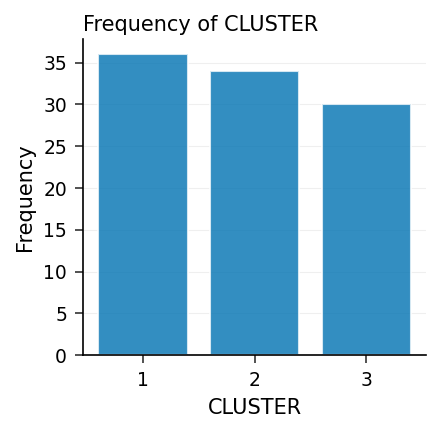

In [5]:
/* přenesení štítku shluku zpět k datům v původním měřítku */
PROCEDURA ŘADIT data=scored(PONECHAT=subscriber_id CLUSTER distance) out=clus_assign;
    PODLE subscriber_id;
SPUSTIT;
PROCEDURA ŘADIT data=subscribers out=subs_sorted;
    PODLE subscriber_id;
SPUSTIT;
data profile;
    SLOUČIT subs_sorted clus_assign;
    PODLE subscriber_id;
SPUSTIT;

/* Kolik účastníků připadlo na jaký segment? */
PROCEDURA ČETNOSTI data=profile;
    ŠTÍTEK CLUSTER="Segment";
    TABLES CLUSTER / nocum;
SPUSTIT;


## 6. Profilace segmentů

ID shluků nemají smysl, dokud nepopíšeme *chování* uvnitř každého z nich. Průměrování původních (nestandardizovaných) ukazatelů podle `CLUSTER` odhalí personu za každým segmentem -- kdo streamuje, kdo telefonuje, kdo síť sotva využívá -- a kategoriální mix ukazuje, které tarify a regiony v každém z nich převažují.


                                                  The MEANS Procedure

                             Analysis Variable : tenure_months Doba u operátora (měsíce)

        Segment           N Obs           Mean
        --------------------------------------
        1                    36           28.9
        2                    34           25.8
        3                    30           28.1
        --------------------------------------

                               Analysis Variable : monthly_data_gb Měsíční data (GB)

        Segment           N Obs           Mean
        --------------------------------------
        1                    36            4.0
        2                    34           10.2
        3                    30           44.4
        --------------------------------------

                                   Analysis Variable : voice_minutes Hlasové minuty

        Segment           N Obs           Mean
        --------------------------------------
        


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_data_plan.spec.json
NOTE: ODS plot written: freq_mosaic_cluster_region.spec.json
NOTE: PROC FREQ statement used.


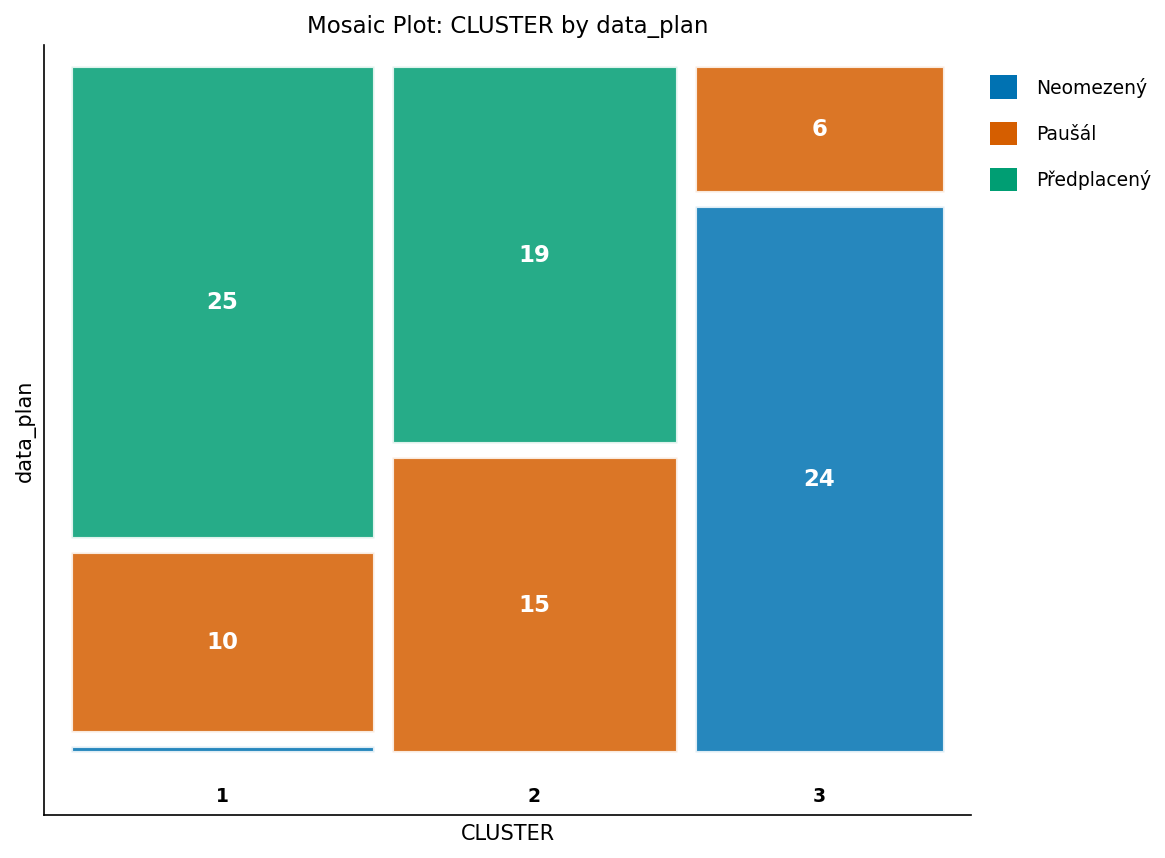

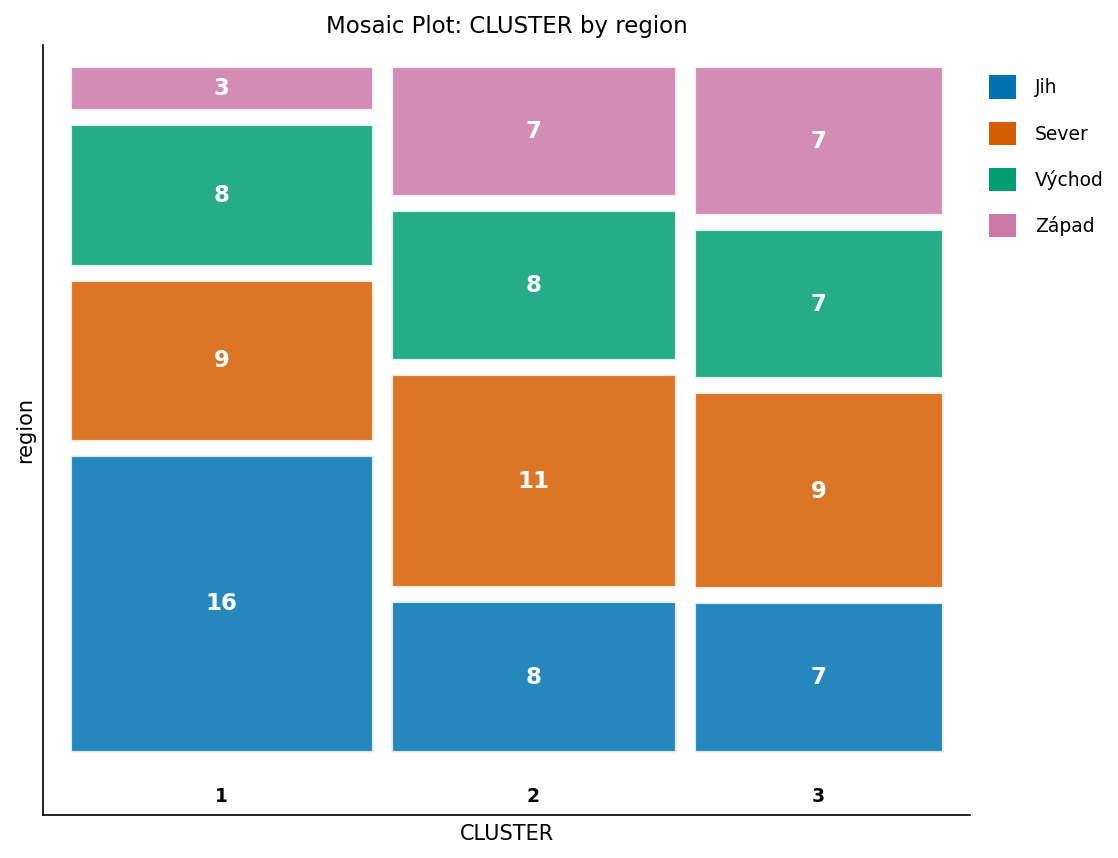

In [6]:
/* Behaviorální profil: průměr každého ukazatele podle segmentu */
PROCEDURA PRŮMĚRY data=profile n mean maxdec=1;
    ŠTÍTEK tenure_months="Doba u operátora (měsíce)" monthly_data_gb="Měsíční data (GB)"
          voice_minutes="Hlasové minuty" sms_count="Počet SMS"
          intl_minutes="Zahraniční minuty" arpu="ARPU ($)" support_calls="Volání na podporu"
          CLUSTER="Segment";
    TŘÍDA CLUSTER;
    PROMĚNNÁ tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
SPUSTIT;

/* Kategoriální mix uvnitř každého segmentu */
PROCEDURA ČETNOSTI data=profile;
    ŠTÍTEK CLUSTER="Segment" data_plan="Tarif" region="Region";
    TABLES CLUSTER * data_plan / norow nopercent;
    TABLES CLUSTER * region    / norow nopercent;
SPUSTIT;


## 7. Vizualizace segmentů

Obrázek udělá segmentaci hmatatelnou. Vykreslíme chuť na data proti hlasovému využití, obarvené podle segmentu, a přidáme krabicový graf ARPU pro každý segment, aby byl příběh o výnosech na první pohled zřejmý.



NOTE: ODS Graphics is ON (width=720px, height=520px, format=SVG).
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


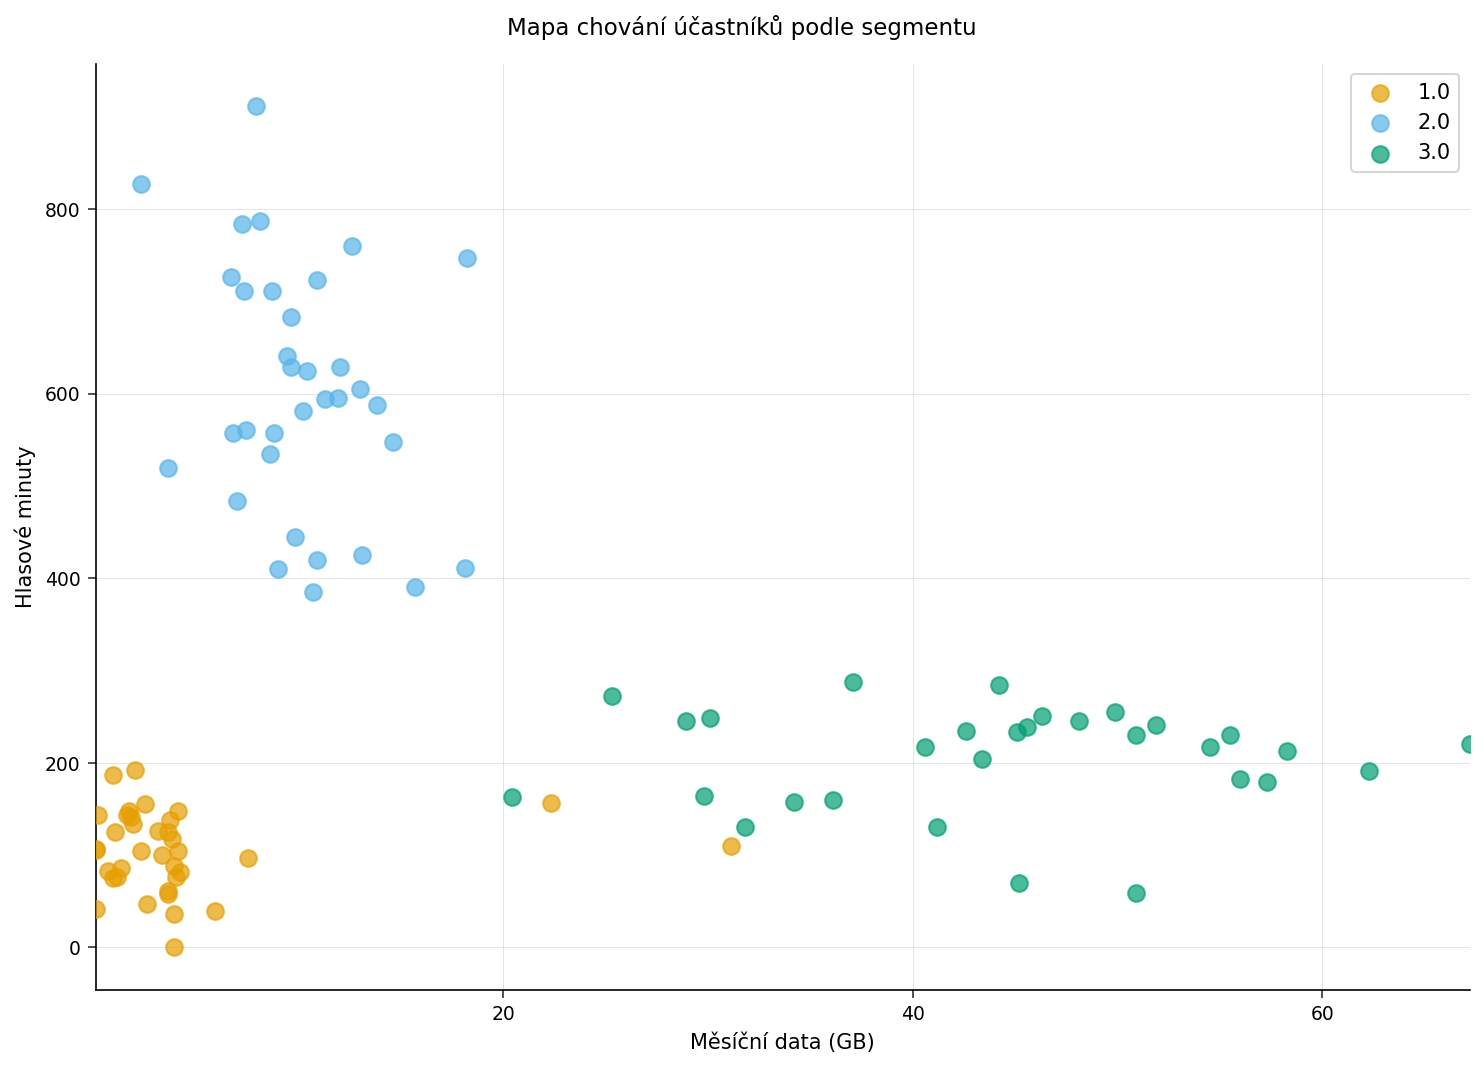

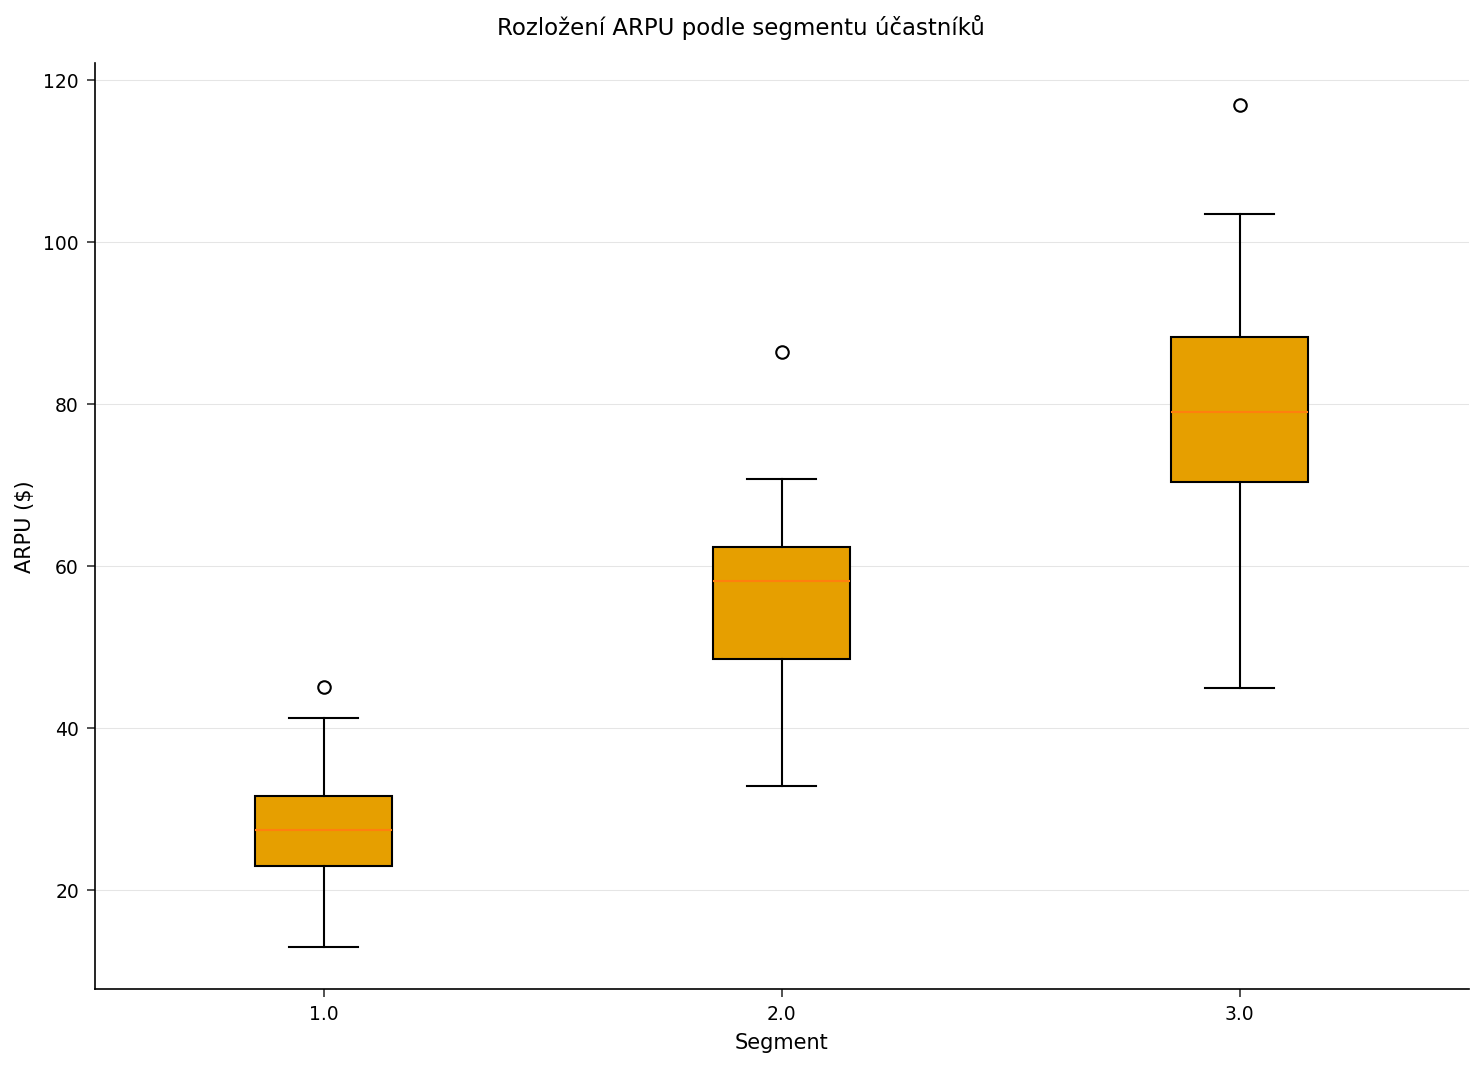

In [7]:
ODS GRAPHICS ON / imagefmt=svg WIDTH=720 HEIGHT=520;

/* Behaviorální mapa: data vs. hlas, obarveno podle segmentu */
PROCEDURA SGPLOT data=profile;
    ŠTÍTEK CLUSTER="Segment";
    SCATTER x=monthly_data_gb y=voice_minutes
            / GROUP=CLUSTER
              MARKERATTRS=(size=8 SYMBOL=circlefilled)
              TRANSPARENCY=0.3;
    XAXIS LABEL='Měsíční data (GB)' grid;
    YAXIS LABEL='Hlasové minuty'     grid;
    NÁZEV 'Mapa chování účastníků podle segmentu';
SPUSTIT;

/* Rozložení výnosů podle segmentu */
PROCEDURA SGPLOT data=profile;
    ŠTÍTEK CLUSTER="Segment";
    VBOX arpu / category=CLUSTER;
    XAXIS LABEL='Segment';
    YAXIS LABEL='ARPU ($)' grid;
    NÁZEV 'Rozložení ARPU podle segmentu účastníků';
SPUSTIT;


## 8. Export ohodnocených segmentů

Nakonec předáme přiřazení navazujícím systémům CRM a kampaní. Ponecháme identifikátor, štítek shluku a hlavní behaviorální pole.


In [8]:
/* Uchování přiřazení segmentů pro aktivaci */
data subscriber_segments;
    NASTAVIT profile;
    PONECHAT subscriber_id CLUSTER tenure_months
         monthly_data_gb voice_minutes arpu data_plan region;
SPUSTIT;

PROCEDURA TISK data=subscriber_segments(obs=10) noobs ŠTÍTEK;
    ŠTÍTEK subscriber_id="ID účastníka" CLUSTER="Segment" tenure_months="Doba u operátora (měsíce)"
          monthly_data_gb="Měsíční data (GB)" voice_minutes="Hlasové minuty" arpu="ARPU ($)"
          data_plan="Tarif" region="Region";
    NÁZEV 'Ukázka ohodnocených segmentů účastníků';
SPUSTIT;


                                         Ukázka ohodnocených segmentů účastníků                                         

   ID účastníka  Segment     Doba u operátora (měsíce)      Měsíční data (GB)   Hlasové minuty  ARPU ($)          Tarif   Region
         100001        1                            30                    2.3              104        28  Předplacený    Jih
         100002        2                             8                   10.2              581     57.78  Předplacený    Západ
         100003        2                             8                   10.7              385     55.66  Paušál         Sever
         100004        2                            68                    7.4              561     70.68  Předplacený    Sever
         100005        3                            18                   45.6              239     63.85  Neomezený      Sever
         100006        3                            10                   30.1              249     88.33  Neomezený 


NOTE: DATA subscriber_segments


NOTE: Read 100 rows from profile.
NOTE: Wrote subscriber_segments (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC PRINT data=subscriber_segments

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## Interpretace výsledků

`PROC FASTCLUS` nalezl tři čisté, dobře oddělené segmenty. Fit je solidní: **celkové R-kvadrát je 0,575** a **pseudo-F je 65,75**, což znamená, že tři shluky vysvětlují přibližně 58 % celkové variability standardizovaných ukazatelů. Oddělení je téměř výhradně dáno behaviorálními signály, na kterých nám záleží -- `voice_minutes` (R-kvadrát 0,858), `monthly_data_gb` (0,844) a `arpu` (0,771) nesou segmentaci, zatímco `tenure_months` (0,000) a `support_calls` (0,193) přispívají téměř nulou, což potvrzuje, že *jak* účastník síť využívá -- nikoli jak dlouho je zákazníkem -- definuje persony.

Tři segmenty se přímo mapují na persony připravené pro marketing, zde profilované v původním (nestandardizovaném) měřítku:

| Segment | n (podíl) | Charakteristické chování | Mix tarifů | Persona | Doporučená akce |
| :-----: | :-------: | ------------------ | -------- | ------- | ---------------- |
| **3** | 30 (30 %) | Nejvyšší data: **44,4 GB/měs.**, nejvyšší útrata **79,1 $ ARPU**, mírný hlas (205 min) | 24/30 **Neomezený** | **Uživatelé s vysokou spotřebou dat** | Ochránit a nabídnout vyšší úroveň: rychlejší tarify, obsahové balíčky, upgrade zařízení |
| **2** | 34 (34 %) | Nejvyšší hlas **603 min/měs.**, **214 SMS**, **106 zahraničních min.**, střední útrata **55,9 $ ARPU** | Předplacený + Paušál, **žádný Neomezený** | **Hlasově orientovaní tradicionalisté** | Mezinárodní doplňky, rodinné/hlasové balíčky, věrnostní odměny |
| **1** | 36 (36 %) | Nejnižší využití: **4,0 GB**, 104 hlasových min., nejnižší útrata **28,0 $ ARPU** | 25/36 **Předplacený** | **Nízké/lehké využití** | Optimalizace tarifů, výzvy k inkasu, levné datové starty pro růst využití |

Mix tarifů potvrzuje behaviorální čtení: segment s vysokou spotřebou dat je z drtivé většiny na tarifech **Neomezený** (24 z 30), segment orientovaný na hlas nemá **žádné** účastníky s tarifem Neomezený a segment s nízkým využitím je většinou **Předplacený** (25 z 36). Region je naproti tomu rovnoměrně rozložen napříč všemi třemi segmenty -- geografie zde není behaviorálním faktorem, což je samo o sobě užitečné zjištění pro cílení kampaní.

**Proč se `PROC FASTCLUS` pro tuto úlohu hodí.** Provádí disjunktní k-means tím, že prochází data postupně místo sestavování úplné matice vzdáleností, takže stejný program, který segmentoval těchto 100 účastníků, škáluje na velmi velké základny. Standardizace pomocí `PROC STDIZE` nejprve odstranila zkreslení dané měřítkem jednotek napříč gigabajty, minutami a dolary, takže každé chování přispívalo do euklidovské vzdálenosti stejnou váhou; diagnostika R-kvadrát pak ukázala, *které* ukazatele skutečně způsobily rozdělení. Ohodnocený výstup -- štítek `CLUSTER` u každého účastníka -- se přímo vloží do aktivačních pipeline a uzavírá tak smyčku od syrového chování k cílené nabídce.

---

<div style="font-size:11px;color:#9e9e9e">Tento notebook slouží pouze pro demonstrační účely. Data jsou syntetická a zjištění nepředstavují obchodní poradenství.</div>
